# Notebook 05 — Microbiome × Villus Layer Interaction

**Scientific question:** Does the microbiome (SPF vs GF) affect gene 
expression differently depending on villus layer position?

Mayassi et al. 2024 showed overall transcriptional robustness to 
microbiome presence across gut regions. This notebook aims to extend 
this finding by asking whether robustness is uniform across the 
crypt-to-villus axis, or whether specific layers are more 
microbiome-sensitive than others.

**Hypothesis:** The villus tip, being directly exposed to the gut lumen, 
is more transcriptionally responsive to microbiome presence than the 
crypt, which is physically protected from luminal bacteria.

## 1. Imports and Paths

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import psutil
import warnings
import os
import gc

warnings.filterwarnings('ignore')
sc.settings.verbosity = 1

PROCESSED_DIR = "/home/wojmor/studies/MODEL/gut_project/data/processed"
FIGURES_DIR  = "/home/wojmor/studies/MODEL/gut_project/results/figures"
TABLES_DIR   = "/home/wojmor/studies/MODEL/gut_project/results/tables"

print("Imports done.")

Imports done.


## 2. Load SI Epithelial Subset

Loads the pre-subsetted AnnData saved at the end of notebook 03 — 
small intestine epithelial spots only.

The data should be already log-normalized from notebook 02.

In [2]:
adata_epi = sc.read_h5ad(f"{PROCESSED_DIR}/visium_si_epithelial.h5ad")

mem = psutil.virtual_memory()
print(f"Loaded: {adata_epi.n_obs} spots × {adata_epi.n_vars} genes")
print(f"Memory used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")
print(f"\nSpots per condition:")
print(adata_epi.obs['microbe'].value_counts())
print(f"\nSpots per layer:")
print(adata_epi.obs['ylayer'].value_counts())
print(f"\nSpots per region:")
print(adata_epi.obs['tissue_region'].value_counts())

Loaded: 84583 spots × 32285 genes
Memory used: 10.0 GB / available: 15.2 GB

Spots per condition:
microbe
GF     36284
SPF    27859
FMT    20440
Name: count, dtype: int64

Spots per layer:
ylayer
Top villous SI       49367
Bottom villous SI    18754
Crypt SI             16462
Name: count, dtype: int64

Spots per region:
tissue_region
Jejunum1    25183
Duodenum    22120
Jejunum2    21622
Ileum       15658
Name: count, dtype: int64


## 3. SPF vs GF DEG Analysis With Downsampling

For each of the 12 region × layer combinations the following steps are performed:
1. Subset to SPF and GF spots only
2. Downsample the larger condition to match the smaller one (random seed = 42)
3. Run Wilcoxon rank-sum test (SPF vs GF)
4. Extract DEGs in both directions

Downsampling ensures equal statistical power for both conditions, 
making DEG counts directly comparable across combinations. 
Without downsampling, combinations with more spots would have higher 
statistical power.
Reproducibility is ensured with a fixed random seed (42).

In [3]:
regions = ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']
layers  = ['Crypt SI', 'Bottom villous SI', 'Top villous SI']

spf_gf_results = {}
deg_counts     = []

for region in regions:
    for layer in layers:
        # Subset to this region × layer, SPF and GF only
        mask = (
            (adata_epi.obs['tissue_region'] == region) &
            (adata_epi.obs['ylayer'] == layer) &
            (adata_epi.obs['microbe'].isin(['SPF', 'GF']))
        )
        adata_sub = adata_epi[mask].copy()

        spf_idx = adata_sub.obs_names[adata_sub.obs['microbe'] == 'SPF']
        gf_idx  = adata_sub.obs_names[adata_sub.obs['microbe'] == 'GF']
        n_spf, n_gf = len(spf_idx), len(gf_idx)

        if n_spf < 50 or n_gf < 50:
            print(f"Skipping {region} × {layer}: SPF={n_spf}, GF={n_gf}")
            del adata_sub; gc.collect()
            continue

        # Downsample to smaller condition
        n_sample = min(n_spf, n_gf)
        np.random.seed(42)
        spf_sampled = np.random.choice(spf_idx, n_sample, replace=False)
        gf_sampled  = np.random.choice(gf_idx,  n_sample, replace=False)
        adata_ds = adata_sub[list(spf_sampled) + list(gf_sampled)].copy()
        del adata_sub; gc.collect()

        # DEG SPF vs GF
        adata_ds.obs['microbe'] = adata_ds.obs['microbe'].astype('category')
        sc.tl.rank_genes_groups(
            adata_ds,
            groupby='microbe',
            groups=['SPF'],
            reference='GF',
            method='wilcoxon',
            key_added='degs_spf_vs_gf',
            pts=True
        )

        # Extract results in both directions (logfoldchanges > 0: higher in SPF, < 0: higher in GF)
        df = sc.get.rank_genes_groups_df(
            adata_ds,
            group='SPF',
            key='degs_spf_vs_gf',
            pval_cutoff=0.05,
        )
        # Filter out genes with Nan logfoldchange (happens when one gene is expressed only in one condition)
        df = df[np.isfinite(df['logfoldchanges'])].copy()
        df['region'] = region
        df['layer']  = layer
        del adata_ds; gc.collect()

        n_spf_up = (df['logfoldchanges'] > 0).sum()
        n_gf_up  = (df['logfoldchanges'] < 0).sum()

        spf_gf_results[f"{region}_{layer}"] = df
        deg_counts.append({
            'region':    region,
            'layer':     layer,
            'n_spf_up':  n_spf_up,
            'n_gf_up':   n_gf_up,
            'n_total':   len(df),
            'n_sample':  n_sample
        })

        print(f"{region} × {layer}: "
              f"SPF↑={n_spf_up}, GF↑={n_gf_up} "
              f"(n={n_sample} per condition)")

# Save full DEG results
all_results = pd.concat(spf_gf_results.values(), ignore_index=True)
all_results.to_csv(f"{TABLES_DIR}/spf_vs_gf_bidirectional.csv", index=False)

deg_counts_df = pd.DataFrame(deg_counts)
deg_counts_df.to_csv(f"{TABLES_DIR}/spf_vs_gf_deg_counts.csv", index=False)

print(f"\nAll results saved.")

mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")

Duodenum × Crypt SI: SPF↑=6040, GF↑=9 (n=1117 per condition)
Duodenum × Bottom villous SI: SPF↑=6600, GF↑=79 (n=1355 per condition)
Duodenum × Top villous SI: SPF↑=416, GF↑=6431 (n=4737 per condition)
Jejunum1 × Crypt SI: SPF↑=1655, GF↑=125 (n=1381 per condition)
Jejunum1 × Bottom villous SI: SPF↑=5595, GF↑=204 (n=2195 per condition)
Jejunum1 × Top villous SI: SPF↑=956, GF↑=6147 (n=4701 per condition)
Jejunum2 × Crypt SI: SPF↑=457, GF↑=179 (n=1198 per condition)
Jejunum2 × Bottom villous SI: SPF↑=4229, GF↑=207 (n=2002 per condition)
Jejunum2 × Top villous SI: SPF↑=1484, GF↑=3224 (n=3213 per condition)
Ileum × Crypt SI: SPF↑=5306, GF↑=205 (n=1555 per condition)
Ileum × Bottom villous SI: SPF↑=3142, GF↑=398 (n=871 per condition)
Ileum × Top villous SI: SPF↑=3719, GF↑=1362 (n=2916 per condition)

All results saved.
Memory used: 10.1 GB / available: 15.1 GB


## 4. Figure — Microbiome Sensitivity Heatmap

Two heatmaps showing the number of significant DEGs per region x layer combination.

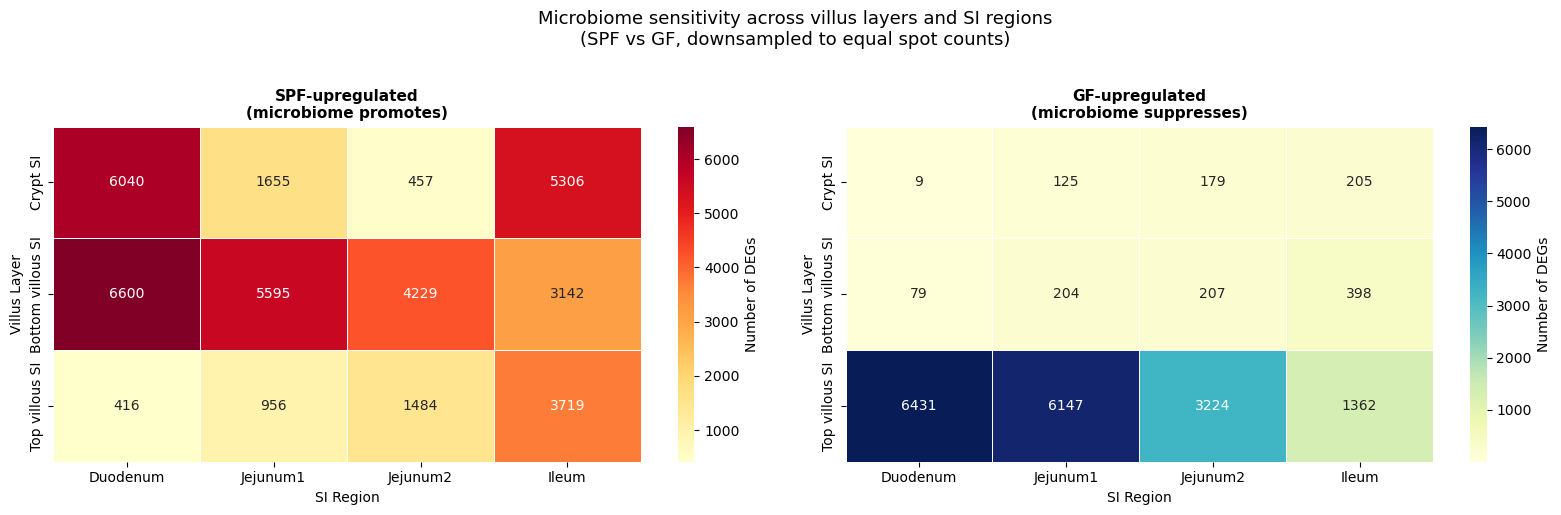

Figure saved.


In [4]:
layer_order  = ['Crypt SI', 'Bottom villous SI', 'Top villous SI']
region_order = ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, (col, title, cmap) in enumerate([
    ('n_spf_up', 'SPF-upregulated\n(microbiome promotes)', 'YlOrRd'),
    ('n_gf_up',  'GF-upregulated\n(microbiome suppresses)', 'YlGnBu')
]):
    pivot = deg_counts_df.pivot(
        index='layer', columns='region', values=col
    ).reindex(index=layer_order, columns=region_order)

    sns.heatmap(
        pivot, ax=axes[ax_idx],
        cmap=cmap, annot=True, fmt='.0f',
        linewidths=0.5,
        cbar_kws={'label': 'Number of DEGs'}
    )
    axes[ax_idx].set_title(title, fontweight='bold', fontsize=11)
    axes[ax_idx].set_xlabel('SI Region')
    axes[ax_idx].set_ylabel('Villus Layer')

plt.suptitle(
    'Microbiome sensitivity across villus layers and SI regions\n'
    '(SPF vs GF, downsampled to equal spot counts)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_microbiome_sensitivity_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 5. GO Enrichment on Most Microbiome-Sensitive Layer

The bottom villous SI is the most SPF-upregulated layer in 3 out 
of 4 SI regions.
GO enrichment identifies which biological processes the microbiome promets in this layer.

In [5]:
# Pool bottom villous DEGs across all four regions
bottom_dfs = [
    spf_gf_results[f"{r}_Bottom villous SI"]
    for r in regions
    if f"{r}_Bottom villous SI" in spf_gf_results
]
bottom_degs = pd.concat(bottom_dfs, ignore_index=True)

# Split by direction with meaningful fold change threshold (log2FC treshold of 0.25 was chosen since microbiome-driven 
# differences are expected to be subtler than differences between distcinc tissue compartments)
spf_up = bottom_degs[bottom_degs['logfoldchanges'] >  0.25]['names'].unique().tolist()
gf_up = bottom_degs[bottom_degs['logfoldchanges'] < -0.25]['names'].unique().tolist()

print(f"Bottom villous SI — SPF-upregulated: {len(spf_up)} genes")
print(f"Bottom villous SI — GF-upregulated:  {len(gf_up)} genes")

Bottom villous SI — SPF-upregulated: 7757 genes
Bottom villous SI — GF-upregulated:  655 genes


In [6]:
go_results = {}

for direction, gene_list, color in [
    ('SPF-upregulated', spf_up, '#e41a1c'),
    ('GF-upregulated',  gf_up,  '#377eb8')
]:
    if len(gene_list) < 10:
        print(f"Skipping {direction} — too few genes ({len(gene_list)})")
        continue

    print(f"Running GO: {direction} ({len(gene_list)} genes)...")
    res = gp.enrichr(
        gene_list=gene_list,
        gene_sets=['GO_Biological_Process_2023'],
        organism='mouse',
        outdir=None,
        cutoff=0.05
    ).results

    sig = res[res['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')
    go_results[direction] = (sig, color)
    sig.to_csv(
        f"{TABLES_DIR}/go_bottom_villous_{direction.lower().replace('-','_')}.csv",
        index=False
    )
    print(f"  → {len(sig)} significant terms saved.")

Running GO: SPF-upregulated (7757 genes)...
  → 842 significant terms saved.
Running GO: GF-upregulated (655 genes)...
  → 0 significant terms saved.


## 6. Figure — GO Enrichment in Bottom Villous SI

Plots the top GO Biological Process terms for SPF-upregulated genes (Bottom Villus SI GF-upregulated is ommitet, since there were no significant terms).

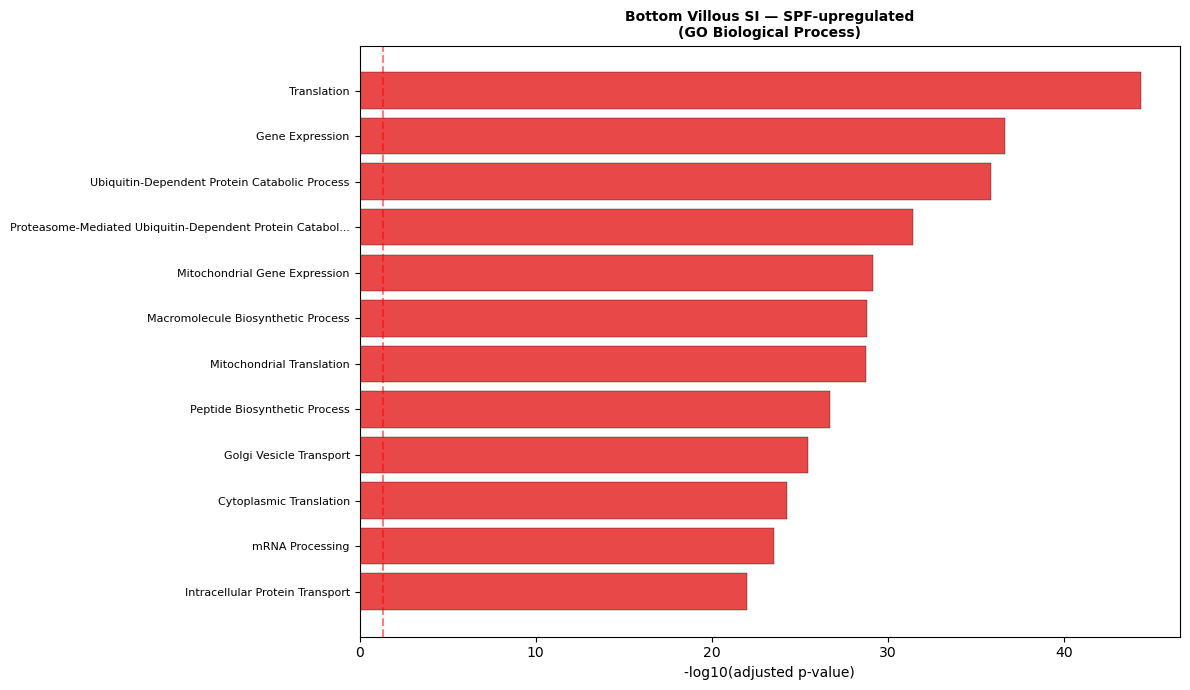

Figure saved.


In [8]:
def plot_go_terms(df, title, color, ax, n_terms=12):
    bp = df[df['Gene_set'].str.contains('Biological_Process')].copy()
    if len(bp) == 0:
        ax.text(0.5, 0.5, 'No significant terms',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')
        return
    top = bp.nsmallest(n_terms, 'Adjusted P-value').copy()
    top['Term_clean'] = top['Term'].str.replace(
        r'\(GO:\d+\)', '', regex=True).str.strip()
    top['neg_log_p'] = -np.log10(top['Adjusted P-value'])
    ax.barh(range(len(top)), top['neg_log_p'].values,
            color=color, alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(
        [t[:55] + '...' if len(t) > 55 else t
         for t in top['Term_clean'].values], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('-log10(adjusted p-value)')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axvline(x=-np.log10(0.05), color='red',
               linestyle='--', alpha=0.5, label='p=0.05')

n_panels = len(go_results)
fig, ax = plt.subplots(figsize=(12, 7))


sig, color = go_results['SPF-upregulated']
plot_go_terms(
    sig,
    'Bottom Villous SI — SPF-upregulated\n(GO Biological Process)',
    color, ax
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_go_bottom_villous.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 7. GO Enrichment on GF-Upregulated Top Villous Genes

Top Villus is, in turn, dominantly upregulated in GF mice.

In [9]:
# Pool GF-upregulated top villous genes across all regions
top_dfs = [
    spf_gf_results[f"{r}_Top villous SI"]
    for r in regions
    if f"{r}_Top villous SI" in spf_gf_results
]
top_degs = pd.concat(top_dfs, ignore_index=True)

# GF-upregulated = microbiome suppresses
gf_up_top = top_degs[
    top_degs['logfoldchanges'] < -0.25
]['names'].unique().tolist()

print(f"Top villous GF-upregulated genes: {len(gf_up_top)}")

print("Running GO enrichment...")
go_top_gf = gp.enrichr(
    gene_list=gf_up_top,
    gene_sets=['GO_Biological_Process_2023'],
    organism='mouse',
    outdir=None,
    cutoff=0.05
).results

go_top_gf_sig = go_top_gf[
    go_top_gf['Adjusted P-value'] < 0.05
].sort_values('Adjusted P-value')

print(f"Significant terms: {len(go_top_gf_sig)}")
go_top_gf_sig.to_csv(
    f"{TABLES_DIR}/go_top_villous_gf_upregulated.csv", index=False
)

Top villous GF-upregulated genes: 7671
Running GO enrichment...
Significant terms: 770


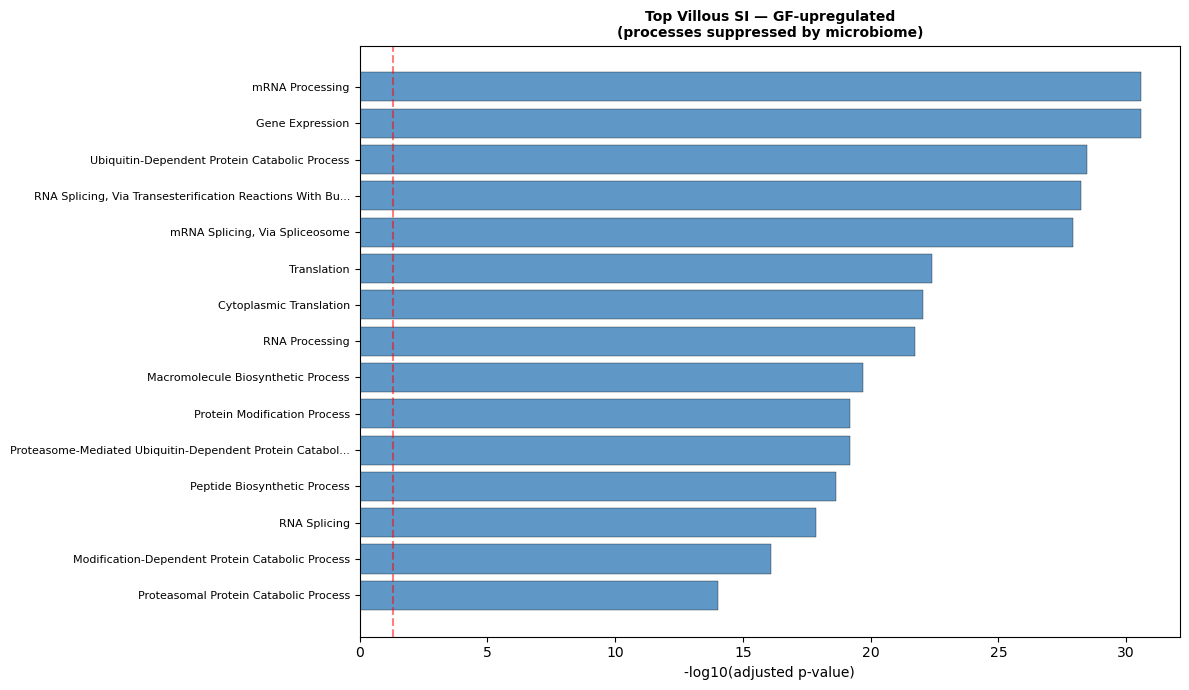

Figure saved.


In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_go_terms(
    go_top_gf_sig,
    'Top Villous SI — GF-upregulated\n(processes suppressed by microbiome)',
    '#377eb8', ax, n_terms=15
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_go_top_villous_gf_up.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")